Versión de TDG: IEC 61083-2 TDG Version 2.1.0
Versión de archivo de datos: Data File Version  2.1.0
Nombre de onda: 01 LI-A1
Resolución de datos: 16 bits
Cantidad de muestras: 10000
Intervalo de muestreo: 10ns
Tasa de muestreo: 1e-08
Datos de la onda:
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003
-50003

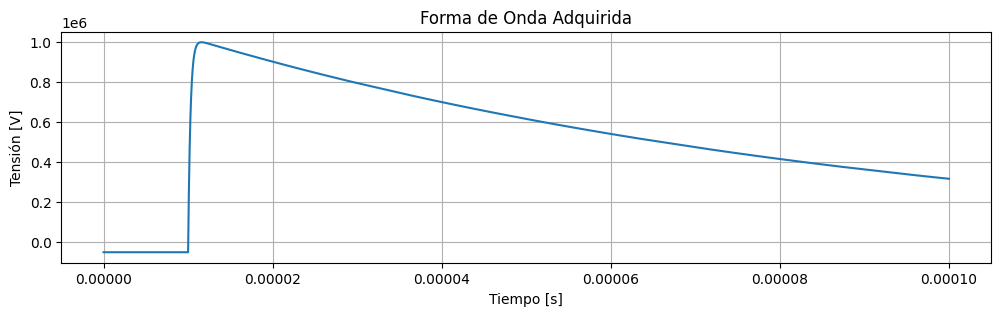

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def read_calibration_file(file_path):
    metadata = {}
    data = []
    
    with open(file_path, 'r') as f:
        
        metadata['sotfware_version'] = f.readline().strip()
        metadata['version_file'] = f.readline().strip()
        metadata['wave_name'] = f.readline().strip()

        line_4 = f.readline().strip()
        resolution_samples_time = line_4.split(',')
        
        metadata['resolution'] = resolution_samples_time[0].strip()
        
        samples_time = resolution_samples_time[1].strip().split(' samples at ')
        metadata['samples'] = int(samples_time[0])
        metadata['interval'] = samples_time[1].strip()

        metadata['rate'] = float(f.readline().strip())

        for line in f:
            if line.strip():
                data.append(int(line.strip()))

    return metadata, data

def print_information(metadata, data):
    print(f"Versión de TDG: {metadata['sotfware_version']}")
    print(f"Versión de archivo de datos: {metadata['version_file']}")
    print(f"Nombre de onda: {metadata['wave_name']}")
    print(f"Resolución de datos: {metadata['resolution']}")
    print(f"Cantidad de muestras: {metadata['samples']}")
    print(f"Intervalo de muestreo: {metadata['interval']}")
    print(f"Tasa de muestreo: {metadata['rate']}")
    print("Datos de la onda:")
    for d in data:
        print(d)
    print(f"\nTotal de puntos extraídos: {len(data)}")

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Tensión [V]")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    calibration_file = 'LI-A1.txt'

    try:
        metadata, signal = read_calibration_file(calibration_file)
        print_information(metadata, signal)
        plot_waveform(signal, metadata['rate'])
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

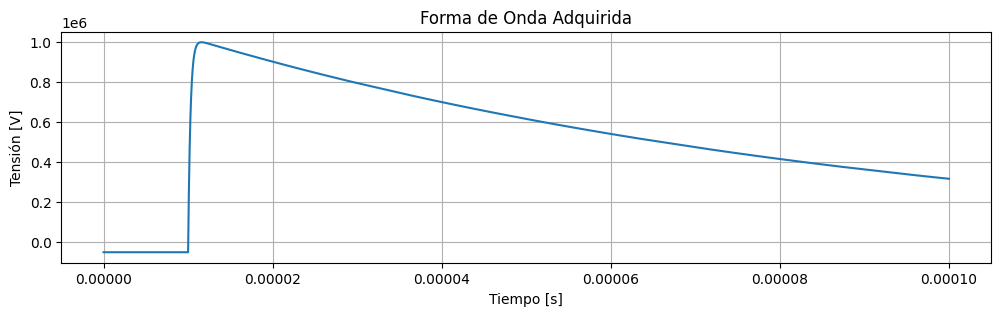

Offset removido: -50003.0 V


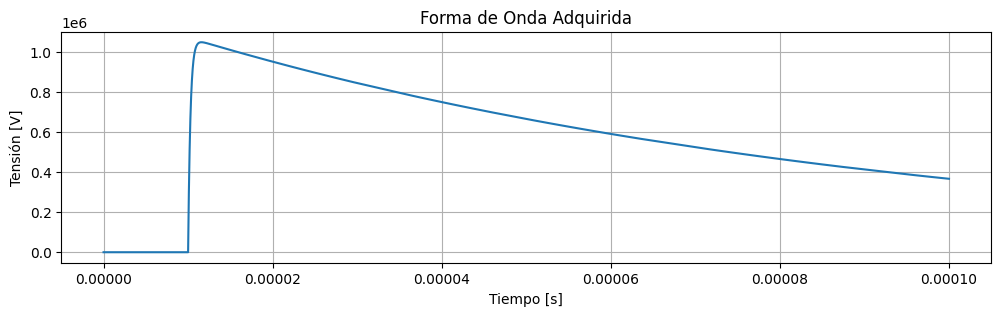

Pico detectado: 1049587.00 V
Polaridad: Positiva


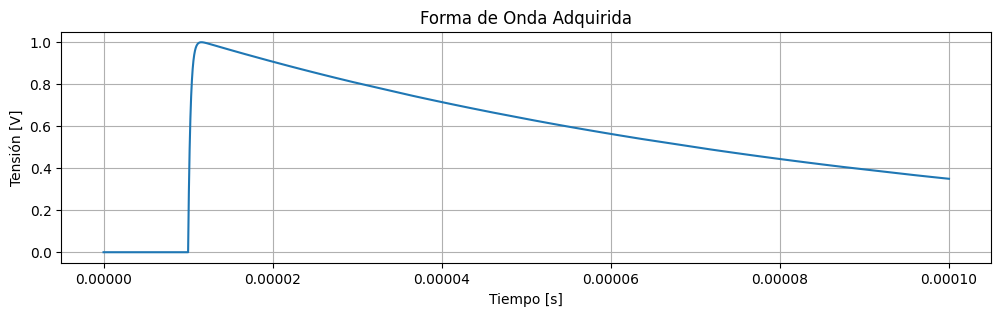

Pico=1049587.0
20% umbral= 209917.40000000002, ID=1007, V=240633.0
40% umbral= 419834.80000000005, ID=8873, V=419769.0
Datos recortados: 7866 muestras seleccionadas para ajuste.


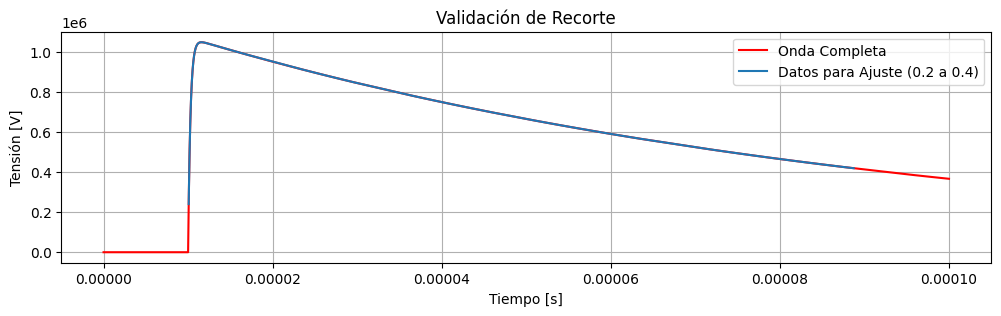

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import DSP

def read_calibration_file(file_path):
    metadata = {}
    data = []
    
    with open(file_path, 'r') as f:
        
        metadata['sotfware_version'] = f.readline().strip()
        metadata['version_file'] = f.readline().strip()
        metadata['wave_name'] = f.readline().strip()

        line_4 = f.readline().strip()
        resolution_samples_time = line_4.split(',')
        
        metadata['resolution'] = resolution_samples_time[0].strip()
        
        samples_time = resolution_samples_time[1].strip().split(' samples at ')
        metadata['samples'] = int(samples_time[0])
        metadata['interval'] = samples_time[1].strip()

        metadata['rate'] = float(f.readline().strip())

        for line in f:
            if line.strip():
                data.append(int(line.strip()))

    return metadata, data

def print_information(metadata, data):
    print(f"Versión de TDG: {metadata['sotfware_version']}")
    print(f"Versión de archivo de datos: {metadata['version_file']}")
    print(f"Nombre de onda: {metadata['wave_name']}")
    print(f"Resolución de datos: {metadata['resolution']}")
    print(f"Cantidad de muestras: {metadata['samples']}")
    print(f"Intervalo de muestreo: {metadata['interval']}")
    print(f"Tasa de muestreo: {metadata['rate']}")
    print("Datos de la onda:")
    for d in data:
        print(d)
    print(f"\nTotal de puntos extraídos: {len(data)}")

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Tensión [V]")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    calibration_file = 'LI-A1.txt'

    try:
        metadata, signal = read_calibration_file(calibration_file)
        #print_information(metadata, signal)
        plot_waveform(signal, metadata['rate'])
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")
    
    # Paso 1: Quitar Offset
    analyzer = DSP.LightningImpulseAnalyzer(signal, metadata['rate'])
    offset = analyzer.remove_offset()
    print(f"Offset removido: {offset} V")
    plot_waveform(analyzer.zeroed_voltage, metadata['rate'])

    # Paso 2: Normalizar y detectar pico
    peak, polarity = analyzer.normalize_waveform()
    print(f"Pico detectado: {peak:.2f} V")
    print(f"Polaridad: {polarity}")
    # Graficar la señal normalizada
    plot_waveform(analyzer.norm_voltage, metadata['rate'])

    # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
    try:
        t_fit, v_fit, v_fit_norm = analyzer.data_for_fitting()
        print(f"Datos recortados: {len(v_fit)} muestras seleccionadas para ajuste.")
        
        # Gráfico de verificación:
        plt.figure(figsize=(12, 3))
        # 1. Onda completa.
        plt.plot(analyzer.time_axis, analyzer.zeroed_voltage, color='red', label='Onda Completa')
        # 2. Parte recortada (sobrepuesta).
        plt.plot(t_fit, v_fit, label='Datos para Ajuste (0.2 a 0.4)')
        plt.title("Validación de Recorte")
        plt.legend()
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Tensión [V]")
        plt.grid(True)
        plt.show()

    except ValueError as e:
        print(e)
    
    # Paso 4: Ajuste de la señal recortada con función de doble exponencial.
    try:
        popt, pcov = analyzer.fit_double_exponential()
        print("Parámetros ajustados de la doble exponencial:")
        print(f"A = {popt[0]:.4f}, tau1 = {popt[1]:.6f} s, tau2 = {popt[2]:.6f} s, td = {popt[3]:.6f} s")
        
        # Graficar el ajuste
        v_fit_adjusted = analyzer.double_exponential(t_fit, *popt)
        
        plt.figure(figsize=(12, 3))
        plt.plot(t_fit, v_fit, 'b.', label='Datos para Ajuste')
        plt.plot(t_fit, v_fit_adjusted, 'r-', label='Ajuste Doble Exponencial')
        plt.title("Ajuste de Doble Exponencial")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Tensión [V]")
        plt.legend()
        plt.grid(True)
        plt.show()